Load Solitude from OSM\n\nParses `data/osm/UT/Solitude.osm` into a `Mountain` object using the new backend (`core/support/mountain.py`). This drives the full ingestion pipeline: OSM parsing → elevation lookup → vertical/difficulty calculation → historical weather lookup.\n\nRun this notebook with the repo root as the working directory (it uses relative paths like `data/cache_db.db`)."

In [29]:
from core.support.mountain import Mountain
from core.datamodels.season_pass import Season_Pass

OSM_FILE = "data/osm/UT/Solitude.osm"

Build the `Mountain` from the OSM file. This hits the real elevation and weather APIs (caching elevation lookups in `data/cache_db.db`), so it can take a bit on first run.

In [30]:
season_passes = [Season_Pass.IKON]
url = "https://www.solitudemountain.com"

mountain = Mountain.from_osm(OSM_FILE, season_passes, url)
mountain

Output()

Output()

Mountain(mountain_id=UUID('3b8b83fd-87d0-3db5-b794-0a1672a3795f'), name='Solitude', state=<State.UTAH: 'UT'>, direction='w', coordinates=<POINT (-111.603 40.613)>, season_passes=[<Season_Pass.IKON: 'Ikon'>], url='https://www.solitudemountain.com', vertical=753, difficulty=49.2, beginner_friendliness=14.9, average_icy_days=55.8, average_snow=173.17, average_rain=0.39, last_updated=datetime.datetime(2026, 8, 9, 22, 50, 18, 393157), trails={'w618345132': Trail(trail_id='w618345132', mountain_id=UUID('3b8b83fd-87d0-3db5-b794-0a1672a3795f'), geometry={'type': 'LineString', 'coordinates': [[Decimal('-111.595014'), Decimal('40.609400'), 2748.333984375], [Decimal('-111.595009'), Decimal('40.609454'), 2747.23974609375], [Decimal('-111.595004'), Decimal('40.609509'), 2746.021240234375], [Decimal('-111.594998'), Decimal('40.609563'), 2744.814453125], [Decimal('-111.594993'), Decimal('40.609617'), 2743.2578125], [Decimal('-111.594988'), Decimal('40.609671'), 2741.515380859375], [Decimal('-111.5949

## Summary stats

In [31]:
print(f"Name: {mountain.name}")
print(f"Mountain ID: {mountain.mountain_id}")
print(f"State: {mountain.state}")
print(f"Region: {mountain.region()}")
print(f"Coordinates: {mountain.coordinates}")
print(f"Direction: {mountain.direction}")
print(f"Vertical: {mountain.vertical} m")
print(f"Difficulty: {mountain.difficulty}")
print(f"Beginner friendliness: {mountain.beginner_friendliness}")
print(f"Average icy days: {mountain.average_icy_days}")
print(f"Average snow: {mountain.average_snow}")
print(f"Average rain: {mountain.average_rain}")
print(f"Trail count: {mountain.trail_count()}")
print(f"Lift count: {mountain.lift_count()}")

Name: Solitude
Mountain ID: 3b8b83fd-87d0-3db5-b794-0a1672a3795f
State: State.UTAH
Region: Region.WEST
Coordinates: POINT (-111.60340338218293 40.61304926725796)
Direction: w
Vertical: 753 m
Difficulty: 49.2
Beginner friendliness: 14.9
Average icy days: 55.8
Average snow: 173.17
Average rain: 0.39
Trail count: 90
Lift count: 9


## Area geometry sampling

Area trails (glades, bowls) store two point sets: `geometry` is the sampled boundary ring, `interior_geometry` is the interior sampling grid used for slope calculations. Plot both for one area trail to sanity-check the sampling.

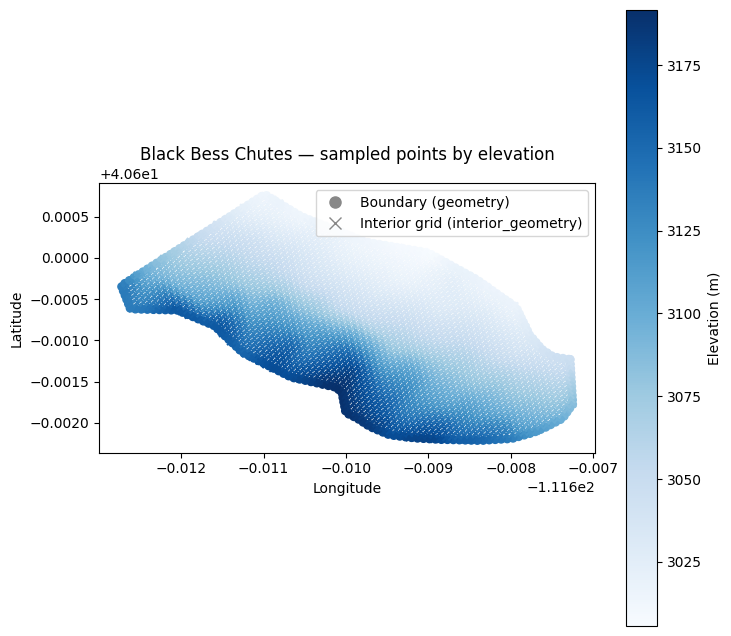

In [32]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

area_trail = next(trail for trail in mountain.trails.values() if trail.area)

boundary_points = area_trail.geometry["coordinates"][0]
interior_points = area_trail.interior_geometry["coordinates"]

boundary_lon, boundary_lat, boundary_elev = zip(*boundary_points)
interior_lon, interior_lat, interior_elev = zip(*interior_points)

all_elev = boundary_elev + interior_elev
vmin, vmax = min(all_elev), max(all_elev)
cmap = plt.get_cmap("Blues")

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(boundary_lon, boundary_lat, color="#c7c7c7", linewidth=1, zorder=1)
points = ax.scatter(
    boundary_lon,
    boundary_lat,
    c=boundary_elev,
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
    marker="o",
    s=30,
    zorder=2,
)
ax.scatter(
    interior_lon,
    interior_lat,
    c=interior_elev,
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
    marker="x",
    s=30,
    zorder=2,
)

# color now encodes elevation, so category (boundary vs. interior) is carried by
# marker shape alone -- legend uses neutral gray proxies to show that mapping
legend_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="none",
        markerfacecolor="#888888",
        markeredgecolor="#888888",
        markersize=8,
        label="Boundary (geometry)",
    ),
    Line2D(
        [0],
        [0],
        marker="x",
        linestyle="none",
        color="#888888",
        markersize=8,
        label="Interior grid (interior_geometry)",
    ),
]
ax.legend(handles=legend_handles)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f"{area_trail.name or area_trail.trail_id} — sampled points by elevation")
ax.set_aspect("equal")

cbar = fig.colorbar(points, ax=ax)
cbar.set_label("Elevation (m)")

plt.show()

## Route finding: least-steep path down

Goal: from a high point on the area's perimeter to a low point, find a ski line whose single steepest pitch is as gentle as possible (a *bottleneck* objective), without turning into a long sideways wander to shave off a fraction of a degree.

**Flexible start/end.** Rather than pinning to the single highest and lowest sampled points, any boundary point within `VERTICAL_BAND_FRACTION` (10%) of the area's vertical drop from the top counts as a valid start, and likewise any boundary point within that fraction of the bottom counts as a valid end. This is implemented as two virtual nodes added to the graph: a virtual start with zero-cost edges to every valid start candidate, and a virtual end with zero-cost edges from every valid end candidate (the standard multi-source/multi-sink shortest-path trick) — the search below then picks whichever real start/end combination works out best, and the virtual nodes are stripped off the final route.

Pure greedy steepest-descent (walk to whichever neighbor is least steep, repeat) can zig-zag or dead-end, since it only ever looks one step ahead. Instead this uses a three-phase approach over a graph built from the sampled points:

1. **Bottleneck pass** — a modified Dijkstra where a path's cost is its *worst* edge, not the sum of edges. This finds the minimum possible steepest-pitch value (`slope_limit`) needed to connect the virtual start to the virtual end at all -- i.e., the gentlest pitch achievable by any valid start/end combination.
2. **Least-wandering pass** — start from a loose slope cap (60°) and tighten it in 5° steps toward `slope_limit`, tracking route length at each cap (ordinary distance-weighted Dijkstra restricted to edges at or below the current cap). The route length at the very first (loosest) pass is the baseline; stop tightening as soon as a cap's route length exceeds a fixed multiple of that baseline (default 1.5x), and use the previous cap — the last one still within budget.
3. **Smoothing pass** — a basic moving average over the route's lon/lat/elevation, replacing each interior point with the average of itself and its immediate neighbors. Plain shortest-path search leaves lots of ties on a lattice-like graph, and Dijkstra breaks them close to arbitrarily, which shows up as zig-zag on the steeper sections where the slope cap prunes most edges down to a narrow, non-straight set of options. Endpoints are left untouched so the route still starts/ends exactly at its chosen top/bottom point. Unlike the graph search, this is *not* slope-validated — a smoothed segment isn't guaranteed to stay under the cap, since it's just blending coordinates rather than checking the same slope formula used to build the graph.

Graph edges only connect points at least `BOTTLENECK_WINDOW_METERS` (30m) apart, capped at `NEIGHBOR_RADIUS_METERS` (45m) so the graph stays local. This mirrors `core/support/utils.py`'s `get_trail_difficulty`, which only counts a pitch if it's sustained over at least 30m (`steepest_30m`) — connecting points ~6-11m apart (the raw `polygon_interior_grid` sample spacing) would make the bottleneck sensitive to noise between two adjacent samples rather than reflecting real sustained steepness. Slope itself is still `atan(rise / run)` in degrees, same as `get_slope_profile`.

In [33]:
import heapq
from collections import defaultdict
from math import atan, degrees

import haversine as hs
import numpy as np

BOTTLENECK_WINDOW_METERS = 30  # matches get_trail_difficulty's steepest_30m -- slope only "counts" if sustained over >= 30m
NEIGHBOR_RADIUS_METERS = BOTTLENECK_WINDOW_METERS * 1.5  # generous margin above the window so the graph stays well-connected near the area boundary
VERTICAL_BAND_FRACTION = 0.10  # perimeter points within this fraction of the vertical drop from the top/bottom are valid start/end candidates

raw_nodes = list(boundary_points) + list(interior_points)
# OSM coordinates come through as Decimal (osm_processor rounds via Decimal());
# cast to float so numpy/math ops downstream work
nodes = [(float(p[0]), float(p[1]), float(p[2])) for p in raw_nodes if p[2] is not None]

node_lon = np.array([p[0] for p in nodes])
node_lat = np.array([p[1] for p in nodes])
node_elev = np.array([p[2] for p in nodes])
n_nodes = len(nodes)

print(
    f"{n_nodes} candidate route nodes ({len(boundary_points)} boundary + {len(interior_points)} interior)"
)

# cheap bounding-box prefilter before paying for an exact haversine call
meters_per_deg_lat = 111_320
meters_per_deg_lon = 111_320 * np.cos(np.radians(node_lat.mean()))
lon_window = NEIGHBOR_RADIUS_METERS / meters_per_deg_lon
lat_window = NEIGHBOR_RADIUS_METERS / meters_per_deg_lat

adjacency = defaultdict(list)  # node index -> [(neighbor index, distance_m, slope_deg), ...]
edge_count = 0

for i in range(n_nodes):
    candidates = np.where(
        (np.abs(node_lon - node_lon[i]) <= lon_window)
        & (np.abs(node_lat - node_lat[i]) <= lat_window)
    )[0]
    for j in candidates:
        if j <= i:
            continue
        dist = hs.haversine(
            (node_lat[i], node_lon[i]), (node_lat[j], node_lon[j]), unit=hs.Unit.METERS
        )
        # only connect points at least BOTTLENECK_WINDOW_METERS apart, so every
        # edge's slope reflects a sustained stretch (same spirit as
        # get_steepest_pitch's 30m window) rather than noise between two
        # adjacent ~20ft samples
        if dist < BOTTLENECK_WINDOW_METERS or dist > NEIGHBOR_RADIUS_METERS:
            continue
        rise = node_elev[j] - node_elev[i]
        slope = abs(degrees(atan(rise / dist)))
        adjacency[i].append((j, dist, slope))
        adjacency[j].append((i, dist, slope))
        edge_count += 1

print(f"{edge_count} candidate edges (avg {2 * edge_count / n_nodes:.1f} neighbors/node)")


def point_slopes(n_nodes, adjacency):
    """
    Average slope (degrees) across each point's incident graph edges --
    slope is an edge property, so this gives a per-point stand-in for
    coloring points by local steepness instead of elevation. Points with
    no edges (rare, near the area boundary) get NaN.
    """
    slopes = np.full(n_nodes, np.nan)
    for i in range(n_nodes):
        edges = adjacency[i]
        if edges:
            slopes[i] = sum(slope for _j, _dist, slope in edges) / len(edges)
    return slopes


node_slopes = point_slopes(n_nodes, adjacency)
# nodes is boundary_points then interior_points, in order (holds as long as no
# points above were dropped for missing elevation)
boundary_slopes = node_slopes[: len(boundary_points)]
interior_slopes = node_slopes[len(boundary_points) :]
print(f"{np.isnan(node_slopes).sum()} points with no edges (excluded from slope coloring)")

2410 candidate route nodes (203 boundary + 2207 interior)
107891 candidate edges (avg 89.5 neighbors/node)
0 points with no edges (excluded from slope coloring)


In [34]:
def add_virtual_endpoints(adjacency, node_elev, n_boundary, vertical_drop_fraction=VERTICAL_BAND_FRACTION):
    """
    Adds two virtual nodes to `adjacency` (indices len(node_elev) and
    len(node_elev) + 1): a virtual start with zero-cost edges to every
    boundary point within the top `vertical_drop_fraction` of the area's
    elevation range, and a virtual end with zero-cost edges FROM every
    boundary point within the bottom `vertical_drop_fraction`. This lets
    the route search treat any high/low-enough point on the perimeter as a
    valid start/end, rather than pinning to the single highest/lowest
    point. Mutates real boundary nodes' adjacency lists (for the end side),
    so must run after anything that reads a real point's own incident
    edges (e.g. point_slopes).

    Returns (virtual_start_idx, virtual_end_idx, start_candidates, end_candidates).
    """
    n_nodes = len(node_elev)
    virtual_start_idx = n_nodes
    virtual_end_idx = n_nodes + 1

    vertical_drop = node_elev.max() - node_elev.min()
    top_threshold = node_elev.max() - vertical_drop_fraction * vertical_drop
    bottom_threshold = node_elev.min() + vertical_drop_fraction * vertical_drop

    start_candidates = [i for i in range(n_boundary) if node_elev[i] >= top_threshold]
    end_candidates = [i for i in range(n_boundary) if node_elev[i] <= bottom_threshold]

    for i in start_candidates:
        adjacency[virtual_start_idx].append((i, 0.0, 0.0))
    for i in end_candidates:
        adjacency[i].append((virtual_end_idx, 0.0, 0.0))

    return virtual_start_idx, virtual_end_idx, start_candidates, end_candidates


virtual_start_idx, virtual_end_idx, start_candidates, end_candidates = add_virtual_endpoints(
    adjacency, node_elev, len(boundary_points)
)
n_nodes_with_virtual = n_nodes + 2

print(
    f"{len(start_candidates)} valid start points (top {VERTICAL_BAND_FRACTION:.0%} of vertical drop), "
    f"{len(end_candidates)} valid end points (bottom {VERTICAL_BAND_FRACTION:.0%})"
)


def bottleneck_dijkstra(adjacency, start, n_nodes):
    """
    Modified Dijkstra where a path's cost is its single worst edge rather
    than the sum of edges -- finds the minimum steepest-pitch needed to
    reach each node from `start`.
    """
    bottleneck = [float("inf")] * n_nodes
    bottleneck[start] = 0.0
    visited = [False] * n_nodes
    heap = [(0.0, start)]

    while heap:
        cost, u = heapq.heappop(heap)
        if visited[u]:
            continue
        visited[u] = True
        for v, _dist, slope in adjacency[u]:
            candidate = max(cost, slope)
            if candidate < bottleneck[v]:
                bottleneck[v] = candidate
                heapq.heappush(heap, (candidate, v))

    return bottleneck


bottleneck = bottleneck_dijkstra(adjacency, virtual_start_idx, n_nodes_with_virtual)
slope_limit = bottleneck[virtual_end_idx]
print(f"Least possible steepest pitch on any route: {slope_limit:.1f} degrees")

28 valid start points (top 10% of vertical drop), 59 valid end points (bottom 10%)
Least possible steepest pitch on any route: 3.4 degrees


In [35]:
def least_wandering_path(adjacency, start, end, n_nodes, slope_limit, epsilon=1e-6):
    """
    Among all routes whose steepest single segment is at or below
    `slope_limit`, find the shortest one (fewest unnecessary detours).
    """
    dist_cost = [float("inf")] * n_nodes
    dist_cost[start] = 0.0
    prev = [None] * n_nodes
    visited = [False] * n_nodes
    heap = [(0.0, start)]

    while heap:
        cost, u = heapq.heappop(heap)
        if visited[u]:
            continue
        visited[u] = True
        if u == end:
            break
        for v, dist, slope in adjacency[u]:
            if slope > slope_limit + epsilon:
                continue
            candidate = cost + dist
            if candidate < dist_cost[v]:
                dist_cost[v] = candidate
                prev[v] = u
                heapq.heappush(heap, (candidate, v))

    if dist_cost[end] == float("inf"):
        return None, None

    path = []
    node = end
    while node is not None:
        path.append(node)
        node = prev[node]
    path.reverse()
    return path, dist_cost[end]


def find_best_max_slope(
    adjacency,
    start,
    end,
    n_nodes,
    slope_limit,
    start_slope=60,
    step=5,
    max_growth_multiplier=1.5,
    verbose=True,
):
    """
    Starts from a loose `start_slope` cap and tightens it toward the
    bottleneck minimum (`slope_limit`) in `step`-degree increments, tracking
    route length at each cap against a fixed baseline: the route length at
    `start_slope` (the first, loosest pass). Stops -- and returns the
    previous cap -- as soon as a route's length exceeds
    `max_growth_multiplier` times that baseline, since it was the last cap
    still within budget of the original length.
    """
    slope_values = []
    s = start_slope
    while s > slope_limit:
        slope_values.append(s)
        s -= step
    slope_values.append(slope_limit)

    best = None  # (max_slope, route_indices, route_length_m)
    baseline_length_m = None

    for max_slope in slope_values:
        route_indices, route_length_m = least_wandering_path(
            adjacency, start, end, n_nodes, max_slope
        )
        if route_indices is None:
            if verbose:
                print(f"max_slope={max_slope:.1f}\N{DEGREE SIGN}: no feasible route")
            break

        if baseline_length_m is None:
            baseline_length_m = route_length_m
            if verbose:
                budget_m = baseline_length_m * max_growth_multiplier
                print(
                    f"max_slope={max_slope:.1f}\N{DEGREE SIGN}: {route_length_m:.0f} m "
                    f"(baseline, budget {max_growth_multiplier:.1f}x = {budget_m:.0f} m)"
                )
        elif verbose:
            print(
                f"max_slope={max_slope:.1f}\N{DEGREE SIGN}: {route_length_m:.0f} m "
                f"({route_length_m / baseline_length_m:.2f}x baseline)"
            )

        if route_length_m > baseline_length_m * max_growth_multiplier:
            if verbose:
                print(
                    f"Stopping: {max_slope:.1f}\N{DEGREE SIGN} exceeds {max_growth_multiplier:.1f}x "
                    f"the baseline length -- keeping {best[0]:.1f}\N{DEGREE SIGN}"
                )
            break

        best = (max_slope, route_indices, route_length_m)

    return best


def point_metrics(point_a, point_b):
    """
    Direct distance (m) and slope (degrees) between two (lon, lat, elev)
    points, regardless of whether they're connected in the graph.
    """
    lon_a, lat_a, elev_a = point_a
    lon_b, lat_b, elev_b = point_b
    dist = hs.haversine((lat_a, lon_a), (lat_b, lon_b), unit=hs.Unit.METERS)
    slope = abs(degrees(atan((elev_a - elev_b) / dist))) if dist > 0 else 0.0
    return dist, slope


def smooth_route(nodes, route_indices, window=1):
    """
    Basic moving-average smoothing: replaces each interior route point with
    the average lon/lat/elevation of itself and its `window` neighbors on
    each side, to reduce the zig-zag from shortest-path tie-breaking on a
    lattice-like graph. Endpoints are left untouched so the route still
    starts/ends exactly at the top/bottom. Unlike a slope-validated
    shortcut, this doesn't guarantee staying under the slope cap -- it's a
    simple smoothing pass, not a constrained one.
    """
    points = [nodes[i] for i in route_indices]
    n = len(points)
    smoothed = [points[0]]

    for i in range(1, n - 1):
        lo = max(0, i - window)
        hi = min(n, i + window + 1)
        neighborhood = points[lo:hi]
        avg_lon = sum(p[0] for p in neighborhood) / len(neighborhood)
        avg_lat = sum(p[1] for p in neighborhood) / len(neighborhood)
        avg_elev = sum(p[2] for p in neighborhood) / len(neighborhood)
        smoothed.append((avg_lon, avg_lat, avg_elev))

    smoothed.append(points[-1])
    return smoothed


max_slope, route_indices, route_length_m = find_best_max_slope(
    adjacency, virtual_start_idx, virtual_end_idx, n_nodes_with_virtual, slope_limit
)

route_indices = route_indices[1:-1]  # drop the virtual start/end bridging nodes
actual_start_idx, actual_end_idx = route_indices[0], route_indices[-1]

route_points = smooth_route(nodes, route_indices, window=1)
route_length_m = sum(
    point_metrics(a, b)[0] for a, b in zip(route_points, route_points[1:])
)
route_slopes = [point_metrics(a, b)[1] for a, b in zip(route_points, route_points[1:])]

print(f"\nChosen max slope: {max_slope:.1f} degrees")
print(f"Start point: {nodes[actual_start_idx][:2]} ({node_elev[actual_start_idx]:.0f} m)")
print(f"End point: {nodes[actual_end_idx][:2]} ({node_elev[actual_end_idx]:.0f} m)")
print(f"Route: {len(route_points)} points, {route_length_m:.0f} m long")
print(
    f"Steepest segment on route: {max(route_slopes):.1f} degrees "
    f"(cap {max_slope:.1f}, bottleneck minimum was {slope_limit:.1f})"
)
print(f"Average segment slope: {sum(route_slopes) / len(route_slopes):.1f} degrees")
print(f"Vertical drop: {node_elev[actual_start_idx] - node_elev[actual_end_idx]:.0f} m")

max_slope=60.0°: 182 m (baseline, budget 1.5x = 273 m)
max_slope=55.0°: 182 m (1.00x baseline)
max_slope=50.0°: 182 m (1.00x baseline)
max_slope=45.0°: 189 m (1.04x baseline)
max_slope=40.0°: 206 m (1.13x baseline)
max_slope=35.0°: 234 m (1.29x baseline)
max_slope=30.0°: 271 m (1.49x baseline)
max_slope=25.0°: 334 m (1.84x baseline)
Stopping: 25.0° exceeds 1.5x the baseline length -- keeping 30.0°

Chosen max slope: 30.0 degrees
Start point: (-111.609348, 40.597836) (3173 m)
End point: (-111.607848, 40.599219) (3024 m)
Route: 8 points, 208 m long
Steepest segment on route: 40.9 degrees (cap 30.0, bottleneck minimum was 3.4)
Average segment slope: 36.4 degrees
Vertical drop: 149 m


Route distance: 208 m (682 ft)


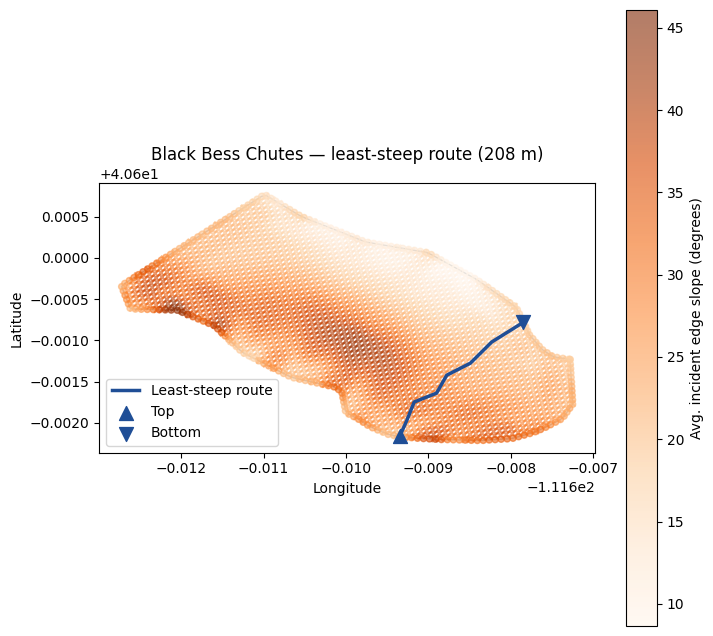

In [36]:
route_lon = [p[0] for p in route_points]
route_lat = [p[1] for p in route_points]

print(f"Route distance: {route_length_m:.0f} m ({route_length_m * 3.28084:.0f} ft)")

slope_vmin, slope_vmax = np.nanmin(node_slopes), np.nanmax(node_slopes)
ROUTE_COLOR = "#1F4E96"  # cool blue reads clearly against the warm Oranges slope ramp

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(boundary_lon, boundary_lat, color="#c7c7c7", linewidth=1, zorder=1)
points = ax.scatter(
    boundary_lon,
    boundary_lat,
    c=boundary_slopes,
    cmap="Oranges",
    vmin=slope_vmin,
    vmax=slope_vmax,
    marker="o",
    s=20,
    alpha=0.6,
    zorder=2,
)
ax.scatter(
    interior_lon,
    interior_lat,
    c=interior_slopes,
    cmap="Oranges",
    vmin=slope_vmin,
    vmax=slope_vmax,
    marker="x",
    s=20,
    alpha=0.6,
    zorder=2,
)
ax.plot(
    route_lon, route_lat, color=ROUTE_COLOR, linewidth=2.5, zorder=3, label="Least-steep route"
)
ax.scatter([route_lon[0]], [route_lat[0]], color=ROUTE_COLOR, marker="^", s=100, zorder=4, label="Top")
ax.scatter(
    [route_lon[-1]], [route_lat[-1]], color=ROUTE_COLOR, marker="v", s=100, zorder=4, label="Bottom"
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f"{area_trail.name or area_trail.trail_id} — least-steep route ({route_length_m:.0f} m)")
ax.set_aspect("equal")
ax.legend()

cbar = fig.colorbar(points, ax=ax)
cbar.set_label("Avg. incident edge slope (degrees)")

plt.show()

## Comparing all areas

Wrap the pipeline above (graph build → bottleneck pass → least-wandering pass) into a function so it can run on any area trail, then apply it to every area trail at Solitude and compare the routes side by side.

In [37]:
def analyze_area_route(
    trail,
    start_slope=70,
    step=1,
    max_growth_multiplier=1.2,
    bottleneck_window_m=BOTTLENECK_WINDOW_METERS,
    max_edge_m=NEIGHBOR_RADIUS_METERS,
    vertical_band_fraction=VERTICAL_BAND_FRACTION,
    smoothing_window=1,
    verbose=False,
):
    """
    Runs the full least-steep, least-wandering route pipeline (graph build,
    virtual start/end injection for any perimeter point within
    `vertical_band_fraction` of the top/bottom, bottleneck pass, tightening
    the slope cap from `start_slope` down until route length exceeds
    `max_growth_multiplier` times its baseline length, then a
    moving-average smoothing pass) for a single area trail.
    Reuses bottleneck_dijkstra/find_best_max_slope/add_virtual_endpoints/
    smooth_route/point_metrics/point_slopes defined above.
    """
    boundary_points = trail.geometry["coordinates"][0]
    interior_points = trail.interior_geometry["coordinates"]

    boundary_lon, boundary_lat, boundary_elev = zip(*boundary_points)
    interior_lon, interior_lat, interior_elev = zip(*interior_points)

    raw_nodes = list(boundary_points) + list(interior_points)
    nodes = [(float(p[0]), float(p[1]), float(p[2])) for p in raw_nodes if p[2] is not None]

    node_lon = np.array([p[0] for p in nodes])
    node_lat = np.array([p[1] for p in nodes])
    node_elev = np.array([p[2] for p in nodes])
    n_nodes = len(nodes)

    meters_per_deg_lat = 111_320
    meters_per_deg_lon = 111_320 * np.cos(np.radians(node_lat.mean()))
    lon_window = max_edge_m / meters_per_deg_lon
    lat_window = max_edge_m / meters_per_deg_lat

    adjacency = defaultdict(list)
    for i in range(n_nodes):
        candidates = np.where(
            (np.abs(node_lon - node_lon[i]) <= lon_window)
            & (np.abs(node_lat - node_lat[i]) <= lat_window)
        )[0]
        for j in candidates:
            if j <= i:
                continue
            dist = hs.haversine(
                (node_lat[i], node_lon[i]), (node_lat[j], node_lon[j]), unit=hs.Unit.METERS
            )
            # only connect points at least bottleneck_window_m apart, so every
            # edge's slope reflects a sustained stretch rather than noise
            # between two adjacent samples
            if dist < bottleneck_window_m or dist > max_edge_m:
                continue
            rise = node_elev[j] - node_elev[i]
            slope = abs(degrees(atan(rise / dist)))
            adjacency[i].append((j, dist, slope))
            adjacency[j].append((i, dist, slope))

    node_slopes = point_slopes(n_nodes, adjacency)
    boundary_slopes = node_slopes[: len(boundary_points)]
    interior_slopes = node_slopes[len(boundary_points) :]

    virtual_start_idx, virtual_end_idx, start_candidates, end_candidates = add_virtual_endpoints(
        adjacency, node_elev, len(boundary_points), vertical_drop_fraction=vertical_band_fraction
    )
    n_nodes_with_virtual = n_nodes + 2

    bottleneck = bottleneck_dijkstra(adjacency, virtual_start_idx, n_nodes_with_virtual)
    slope_limit = bottleneck[virtual_end_idx]

    max_slope, route_indices, route_length_m = find_best_max_slope(
        adjacency,
        virtual_start_idx,
        virtual_end_idx,
        n_nodes_with_virtual,
        slope_limit,
        start_slope=start_slope,
        step=step,
        max_growth_multiplier=max_growth_multiplier,
        verbose=verbose,
    )

    route_indices = route_indices[1:-1]  # drop the virtual start/end bridging nodes
    actual_start_idx, actual_end_idx = route_indices[0], route_indices[-1]

    route_points = smooth_route(nodes, route_indices, window=smoothing_window)
    route_length_m = sum(
        point_metrics(a, b)[0] for a, b in zip(route_points, route_points[1:])
    )
    route_slopes = [
        point_metrics(a, b)[1] for a, b in zip(route_points, route_points[1:])
    ]

    return {
        "trail": trail,
        "boundary_lon": boundary_lon,
        "boundary_lat": boundary_lat,
        "boundary_elev": boundary_elev,
        "boundary_slopes": boundary_slopes,
        "interior_lon": interior_lon,
        "interior_lat": interior_lat,
        "interior_elev": interior_elev,
        "interior_slopes": interior_slopes,
        "nodes": nodes,
        "route_points": route_points,
        "route_length_m": route_length_m,
        "route_slopes": route_slopes,
        "slope_limit": slope_limit,
        "max_slope": max_slope,
        "vertical_drop_m": node_elev[actual_start_idx] - node_elev[actual_end_idx],
        "n_start_candidates": len(start_candidates),
        "n_end_candidates": len(end_candidates),
    }


area_trails = [trail for trail in mountain.trails.values() if trail.area]

print(f"{len(area_trails)} area trails found at {mountain.name}")
for i, trail in enumerate(area_trails, start=1):
    print(f"  {i}. {trail.name or trail.trail_id}")

results = [analyze_area_route(trail) for trail in area_trails]

for r in results:
    trail_label = r["trail"].name or r["trail"].trail_id
    print(
        f"\n{trail_label}: {r['route_length_m']:.0f} m route, "
        f"steepest {max(r['route_slopes']):.1f}\N{DEGREE SIGN} "
        f"(cap {r['max_slope']:.1f}\N{DEGREE SIGN}, bottleneck min {r['slope_limit']:.1f}\N{DEGREE SIGN}), "
        f"{r['vertical_drop_m']:.0f} m vertical"
    )

5 area trails found at Solitude
  1. Black Bess Chutes
  2. Honeycomb Chutes
  3. Boundry Chutes
  4. No Man's Land
  5. Crystal Point

Black Bess Chutes: 206 m route, steepest 39.1° (cap 38.0°, bottleneck min 3.4°), 149 m vertical

Honeycomb Chutes: 206 m route, steepest 44.0° (cap 44.0°, bottleneck min 2.7°), 196 m vertical

Boundry Chutes: 588 m route, steepest 28.2° (cap 27.0°, bottleneck min 2.6°), 281 m vertical

No Man's Land: 609 m route, steepest 32.6° (cap 23.0°, bottleneck min 7.9°), 258 m vertical

Crystal Point: 390 m route, steepest 38.6° (cap 30.0°, bottleneck min 2.2°), 217 m vertical


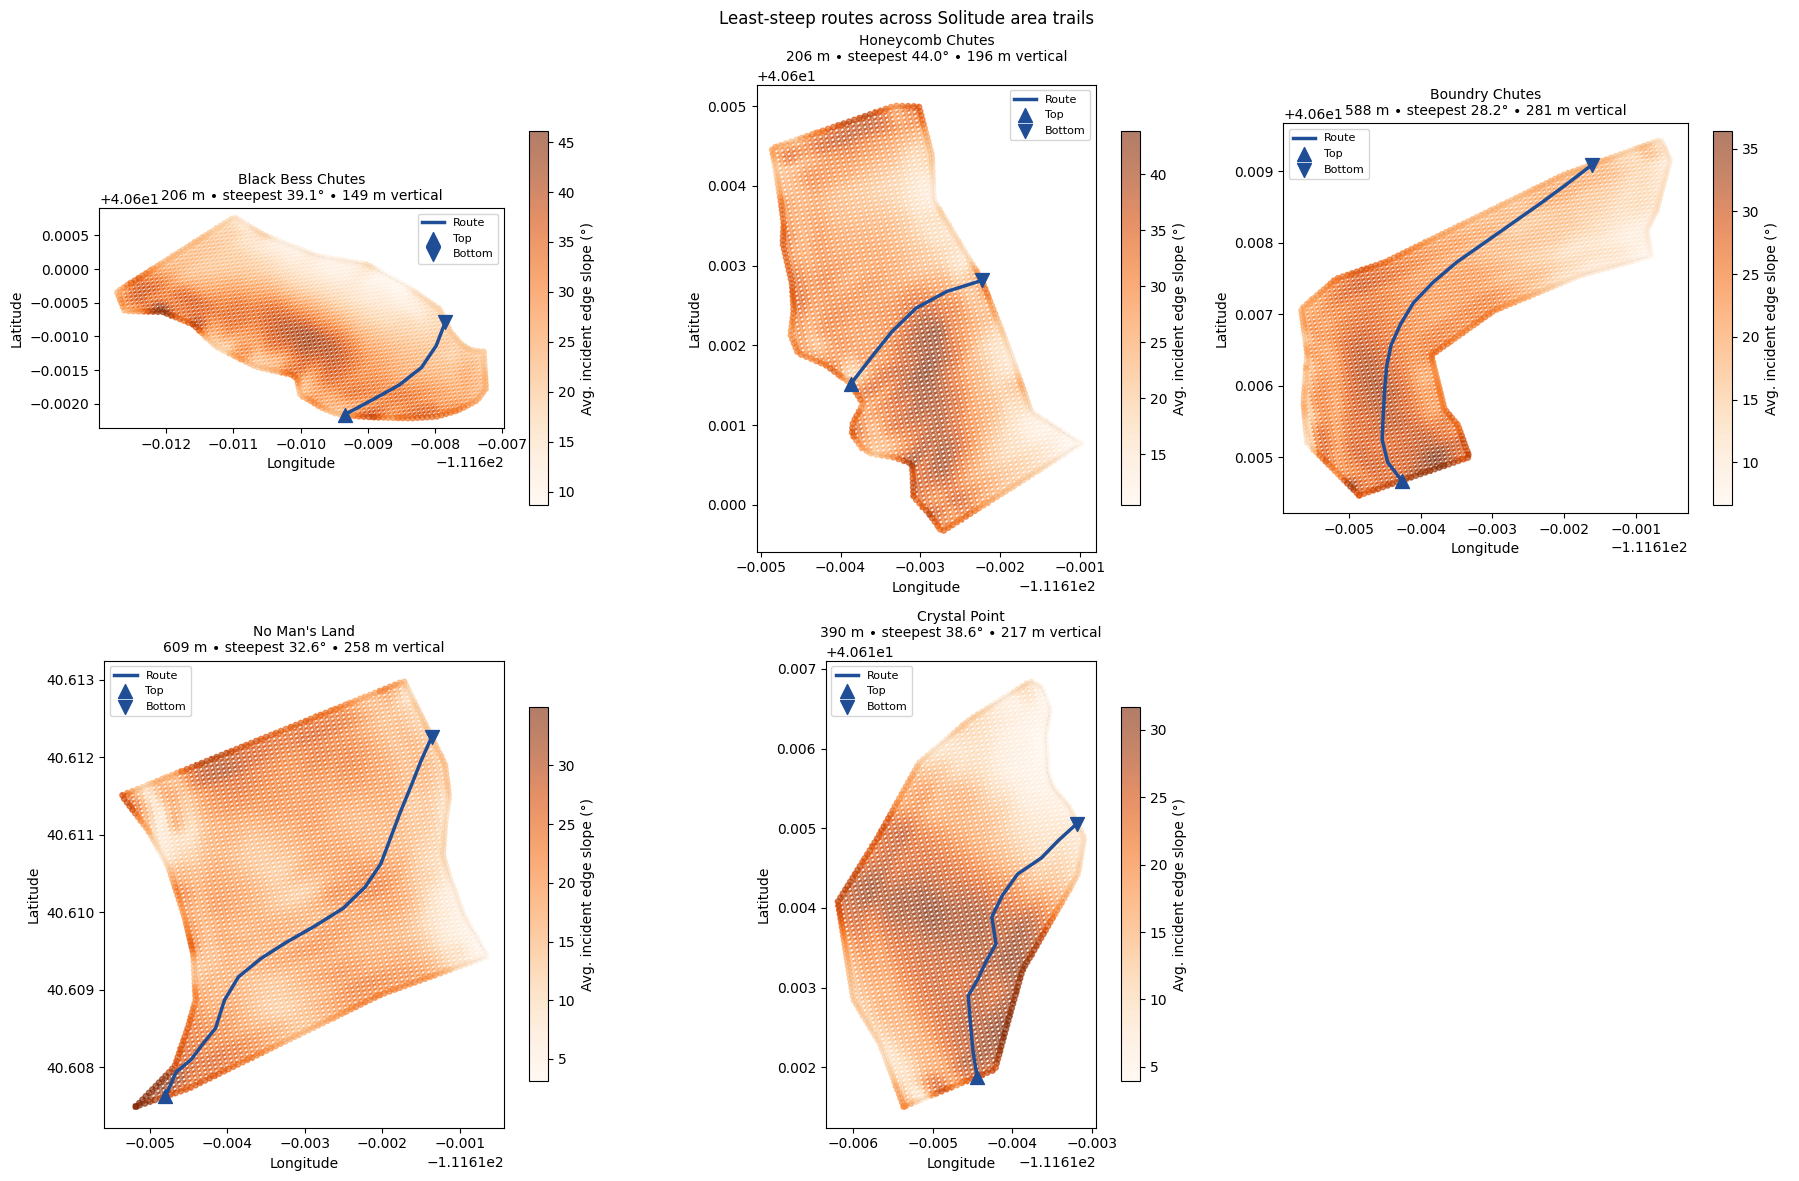

In [38]:
def plot_area_routes(results, title):
    """
    Plots a grid of area-trail maps (small multiples), each showing the
    sampled points colored by local slope and the least-steep route
    overlaid. Reusable across any Mountain's list of analyze_area_route
    results.
    """
    n_results = len(results)
    ncols = min(3, n_results)
    nrows = -(-n_results // ncols)  # ceiling division

    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 6 * nrows))
    axes = np.atleast_1d(axes).flatten()
    route_color = "#1F4E96"  # cool blue reads clearly against the warm Oranges slope ramp

    for ax, r in zip(axes, results):
        trail = r["trail"]
        all_slopes = np.concatenate([r["boundary_slopes"], r["interior_slopes"]])
        vmin, vmax = np.nanmin(all_slopes), np.nanmax(all_slopes)

        ax.plot(r["boundary_lon"], r["boundary_lat"], color="#c7c7c7", linewidth=1, zorder=1)
        points = ax.scatter(
            r["boundary_lon"],
            r["boundary_lat"],
            c=r["boundary_slopes"],
            cmap="Oranges",
            vmin=vmin,
            vmax=vmax,
            marker="o",
            s=15,
            alpha=0.6,
            zorder=2,
        )
        ax.scatter(
            r["interior_lon"],
            r["interior_lat"],
            c=r["interior_slopes"],
            cmap="Oranges",
            vmin=vmin,
            vmax=vmax,
            marker="x",
            s=15,
            alpha=0.6,
            zorder=2,
        )

        route_lon = [p[0] for p in r["route_points"]]
        route_lat = [p[1] for p in r["route_points"]]
        ax.plot(route_lon, route_lat, color=route_color, linewidth=2.5, zorder=3, label="Route")
        ax.scatter(
            [route_lon[0]], [route_lat[0]], color=route_color, marker="^", s=100, zorder=4, label="Top"
        )
        ax.scatter(
            [route_lon[-1]], [route_lat[-1]], color=route_color, marker="v", s=100, zorder=4, label="Bottom"
        )

        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
        ax.set_title(
            f"{trail.name or trail.trail_id}\n"
            f"{r['route_length_m']:.0f} m \N{BULLET OPERATOR} steepest {max(r['route_slopes']):.1f}\N{DEGREE SIGN} "
            f"\N{BULLET OPERATOR} {r['vertical_drop_m']:.0f} m vertical",
            fontsize=10,
        )
        ax.set_aspect("equal")
        ax.legend(fontsize=8)

        fig.colorbar(points, ax=ax, label="Avg. incident edge slope (\N{DEGREE SIGN})", shrink=0.8)

    for ax in axes[n_results:]:
        ax.axis("off")

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


plot_area_routes(results, f"Least-steep routes across {mountain.name} area trails")

### Steepest sustained pitches

Reuse `core/support/utils.py`'s `get_steepest_pitch` (the same function used to rate real trails) on each route's point sequence, to see the steepest slope sustained over any 30m/50m/100m stretch -- a different view than the single steepest *segment* printed above, since a route can have one sharp short segment without necessarily having a steep sustained pitch, or vice versa.

In [39]:
from core.support.utils import get_steepest_pitch

for r in results:
    trail_label = r["trail"].name or r["trail"].trail_id
    route_geometry = {"coordinates": r["route_points"]}

    steepest_30m = get_steepest_pitch(route_geometry, 30)
    steepest_50m = get_steepest_pitch(route_geometry, 50)
    steepest_100m = get_steepest_pitch(route_geometry, 100)

    print(f"{trail_label}:")
    print(f"  Steepest 30m pitch: {steepest_30m}\N{DEGREE SIGN}")
    print(f"  Steepest 50m pitch: {steepest_50m}\N{DEGREE SIGN}")
    print(f"  Steepest 100m pitch: {steepest_100m}\N{DEGREE SIGN}")

Black Bess Chutes:
  Steepest 30m pitch: 39.1°
  Steepest 50m pitch: 38.4°
  Steepest 100m pitch: 38.3°
Honeycomb Chutes:
  Steepest 30m pitch: 44.0°
  Steepest 50m pitch: 43.9°
  Steepest 100m pitch: 43.8°
Boundry Chutes:
  Steepest 30m pitch: 28.2°
  Steepest 50m pitch: 28.1°
  Steepest 100m pitch: 27.5°
No Man's Land:
  Steepest 30m pitch: 32.4°
  Steepest 50m pitch: 32.4°
  Steepest 100m pitch: 28.9°
Crystal Point:
  Steepest 30m pitch: 38.4°
  Steepest 50m pitch: 38.4°
  Steepest 100m pitch: 35.6°


## Another mountain: Crystal Mountain, WA

Sanity-check that the pipeline generalizes: load a different resort's OSM extract and run the same area-route analysis and chart on it.

In [40]:
CRYSTAL_OSM_FILE = "data/osm/WA/Crystal Mountain.osm"

crystal_season_passes = [Season_Pass.IKON]
crystal_url = "https://www.crystalmountainresort.com"

crystal_mountain = Mountain.from_osm(CRYSTAL_OSM_FILE, crystal_season_passes, crystal_url)
crystal_mountain

Output()

Output()

Mountain(mountain_id=UUID('ce027ee4-d6e2-3d17-b150-1313770f77f9'), name='Crystal Mountain', state=<State.WASHINGTON: 'WA'>, direction='w', coordinates=<POINT (-121.492 46.934)>, season_passes=[<Season_Pass.IKON: 'Ikon'>], url='https://www.crystalmountainresort.com', vertical=950, difficulty=52.5, beginner_friendliness=16.2, average_icy_days=66.8, average_snow=294.41, average_rain=11.58, last_updated=datetime.datetime(2026, 8, 9, 22, 50, 18, 393157), trails={'w127126791': Trail(trail_id='w127126791', mountain_id=UUID('ce027ee4-d6e2-3d17-b150-1313770f77f9'), geometry={'type': 'LineString', 'coordinates': [[Decimal('-121.489905'), Decimal('46.927690'), 1646.0238037109375], [Decimal('-121.489944'), Decimal('46.927738'), 1643.714111328125], [Decimal('-121.489983'), Decimal('46.927786'), 1642.2159423828125], [Decimal('-121.490023'), Decimal('46.927834'), 1641.259765625], [Decimal('-121.490062'), Decimal('46.927882'), 1640.7137451171875], [Decimal('-121.490101'), Decimal('46.927930'), 1639.38

In [41]:
crystal_area_trails = [trail for trail in crystal_mountain.trails.values() if trail.area]

print(f"{len(crystal_area_trails)} area trails found at {crystal_mountain.name}")
for i, trail in enumerate(crystal_area_trails, start=1):
    print(f"  {i}. {trail.name or trail.trail_id}")

crystal_results = [analyze_area_route(trail) for trail in crystal_area_trails]

for r in crystal_results:
    trail_label = r["trail"].name or r["trail"].trail_id
    print(
        f"\n{trail_label}: {r['route_length_m']:.0f} m route, "
        f"steepest {max(r['route_slopes']):.1f}\N{DEGREE SIGN} "
        f"(cap {r['max_slope']:.1f}\N{DEGREE SIGN}, bottleneck min {r['slope_limit']:.1f}\N{DEGREE SIGN}), "
        f"{r['vertical_drop_m']:.0f} m vertical"
    )

8 area trails found at Crystal Mountain
  1. Bear Pits
  2. w270510669
  3. Silver basin
  4. Bruce's Bowl
  5. Paradise Bowl
  6. Northway Bowl
  7. Snorting Elk Bowl
  8. Lower Change

Bear Pits: 457 m route, steepest 41.7° (cap 32.0°, bottleneck min 2.8°), 289 m vertical

w270510669: 80 m route, steepest 32.6° (cap 31.0°, bottleneck min 2.6°), 51 m vertical

Silver basin: 584 m route, steepest 37.3° (cap 28.0°, bottleneck min 1.8°), 300 m vertical

Bruce's Bowl: 157 m route, steepest 26.6° (cap 26.0°, bottleneck min 2.4°), 77 m vertical

Paradise Bowl: 277 m route, steepest 40.1° (cap 30.0°, bottleneck min 2.9°), 169 m vertical

Northway Bowl: 253 m route, steepest 41.8° (cap 32.0°, bottleneck min 2.9°), 153 m vertical

Snorting Elk Bowl: 460 m route, steepest 19.5° (cap 20.0°, bottleneck min 2.9°), 149 m vertical

Lower Change: 293 m route, steepest 29.1° (cap 24.0°, bottleneck min 1.6°), 125 m vertical


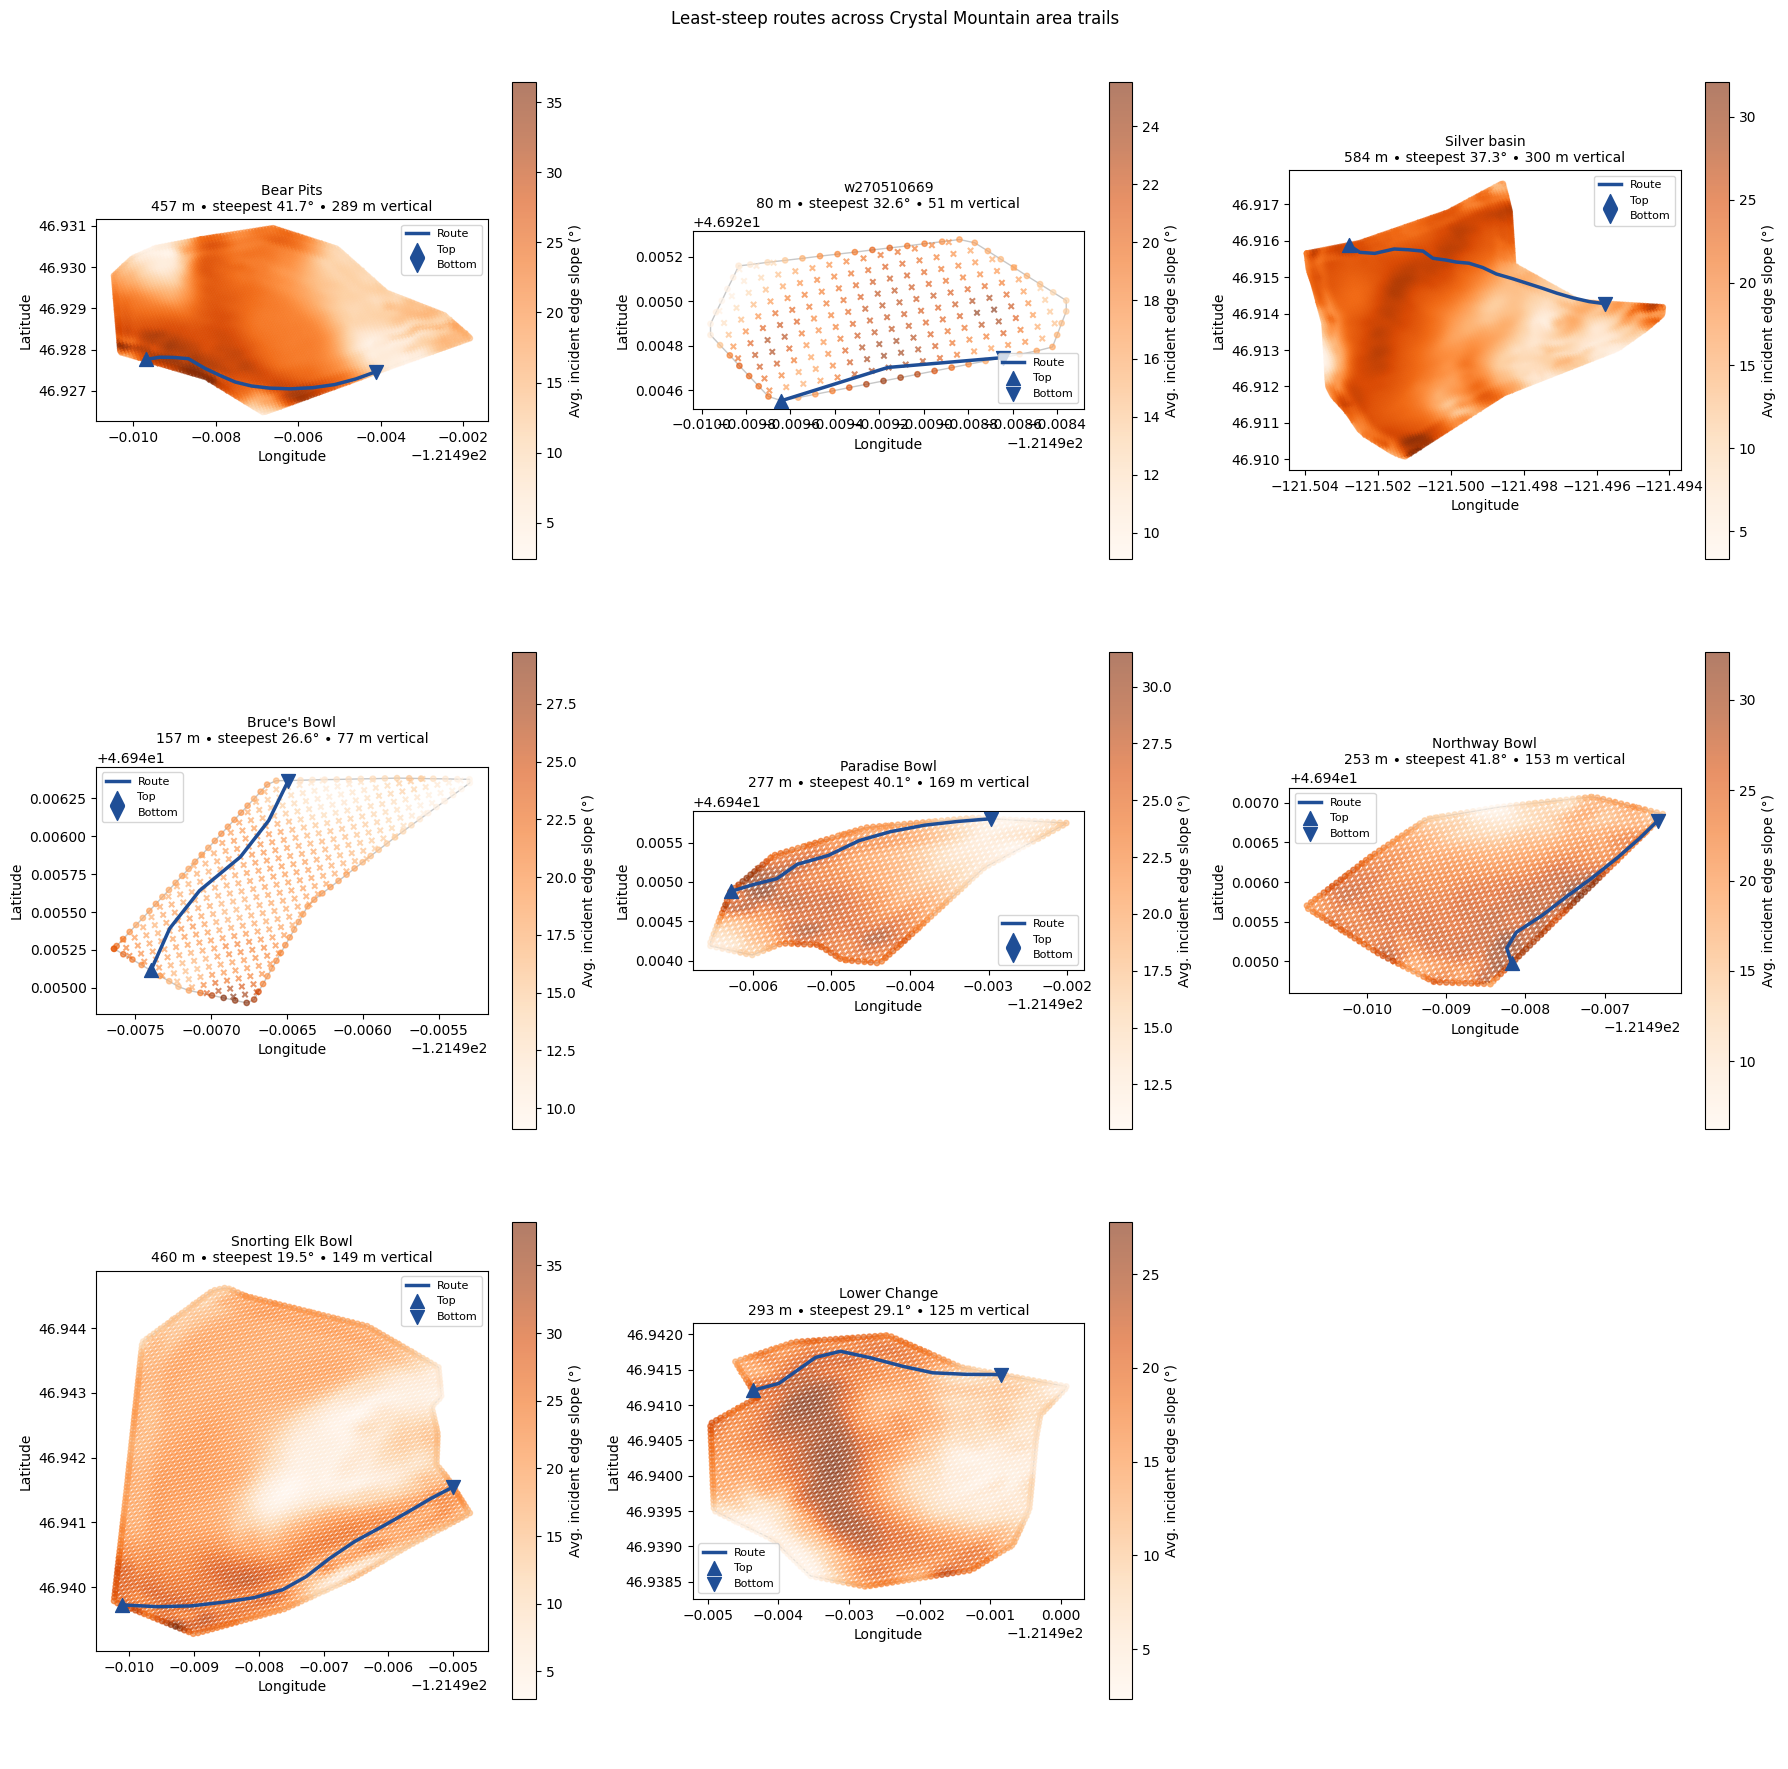

In [42]:
plot_area_routes(crystal_results, f"Least-steep routes across {crystal_mountain.name} area trails")